In [2]:
import os
import datetime
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import colorcet as cc
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import pandas as pd
from bokeh.plotting import figure, output_notebook, show
from bokeh.models import HoverTool, Title
from pathlib import Path
import folium
import rioxarray
import netCDF4

from shapely.geometry import box

from blackmarble.extract import bm_extract
from blackmarble.raster import bm_raster

import xarray as xr
import numpy as np

#Local Functions
import sys
sys.path.append(r'c:\Users\samsa\Documents\NTL_Somaliland\src')
from ntl_functions import plot_NASA_NTL, filter_dataset_by_bounding_box, mask_dataset_by_geometry

#Settings
%load_ext autoreload
%autoreload 2

plt.rcParams["figure.figsize"] = (18, 10)
pd.set_option('display.max_rows', 50)

In [3]:
SL_Berbera_VNP46A4_EY_2012_24 = xr.open_dataset("../data/NTL_Data_A4/SL_Berbera_VNP46A4_EY_2012_24.nc")
V2_VNP46A4_EY_2012_24 = xr.open_dataset("../data/NTL_Data_A4/V2_SL_VNP46A4_EY_2012_24.nc")


In [4]:
print(V2_VNP46A4_EY_2012_24["NearNadir_Composite_Snow_Free"].max())
V2_VNP46A4_EY_2012_24["NearNadir_Composite_Snow_Free"].stack(z=("time", "y", "x")).idxmax()


<xarray.DataArray 'NearNadir_Composite_Snow_Free' ()>
array(175.)


<xarray.DataArray 'z' ()>
array((Timestamp('2023-01-01 00:00:00'), 10.431372070312499, 44.9938720703125),
      dtype=object)
Coordinates:
    time     datetime64[ns] 2023-01-01
    y        float64 10.43
    x        float64 44.99

In [5]:
print(SL_Berbera_VNP46A4_EY_2012_24.max())
SL_Berbera_VNP46A4_EY_2012_24["NearNadir_Composite_Snow_Free"].stack(z=("time", "y", "x")).idxmax()



<xarray.Dataset>
Dimensions:                        ()
Data variables:
    NearNadir_Composite_Snow_Free  float64 198.9


<xarray.DataArray 'z' ()>
array((Timestamp('2023-01-01 00:00:00'), 10.435421981811524, 44.9938720703125),
      dtype=object)
Coordinates:
    time     datetime64[ns] 2023-01-01
    y        float64 10.44
    x        float64 44.99

In [6]:
Berbera = gpd.read_file("../data/Combined_Datasets/Berbera_shp/Berbera.shp")
Berbera_NTL_ber = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Berbera)
Berbera_NTL_v2 = filter_dataset_by_bounding_box(V2_VNP46A4_EY_2012_24, Berbera)


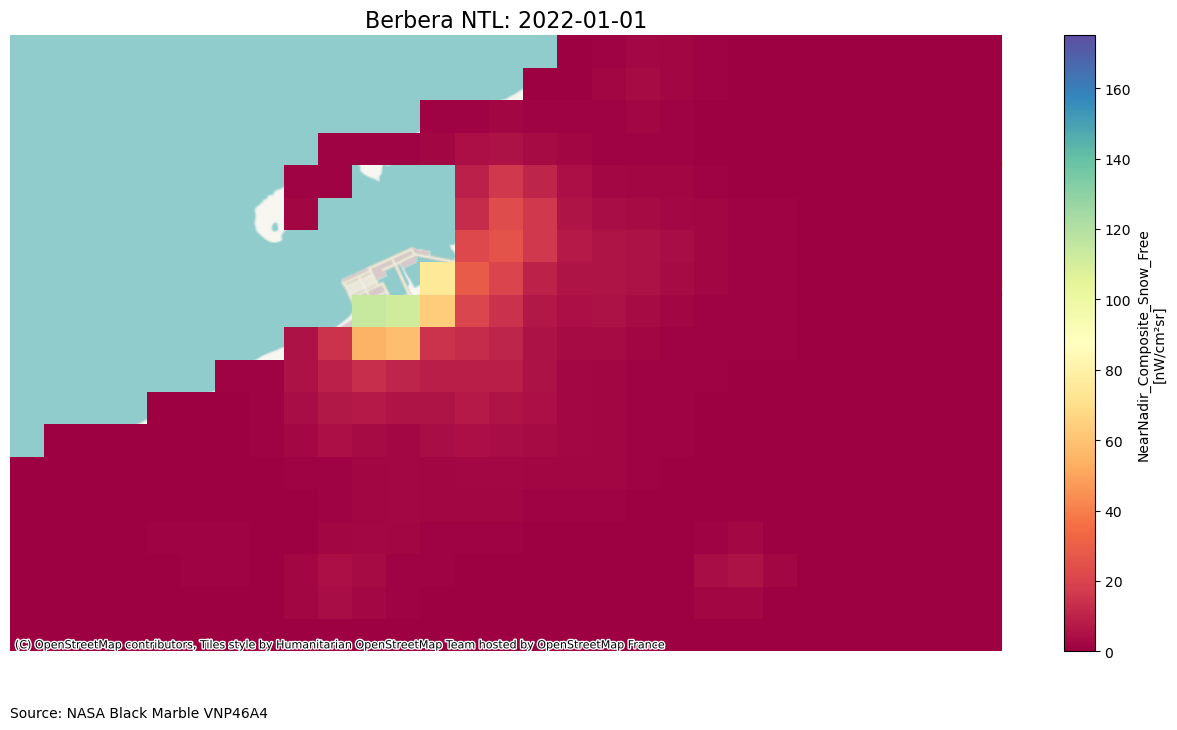

In [7]:
plot_NASA_NTL(Berbera_NTL_v2, Berbera, date = "2022-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Berbera NTL",
              robust = False, vmin=0, vmax = Berbera_NTL_v2["NearNadir_Composite_Snow_Free"].max())
#plt.savefig(f'../output/Graphics/HGA_2012.png', dpi=300, bbox_inches='tight')  

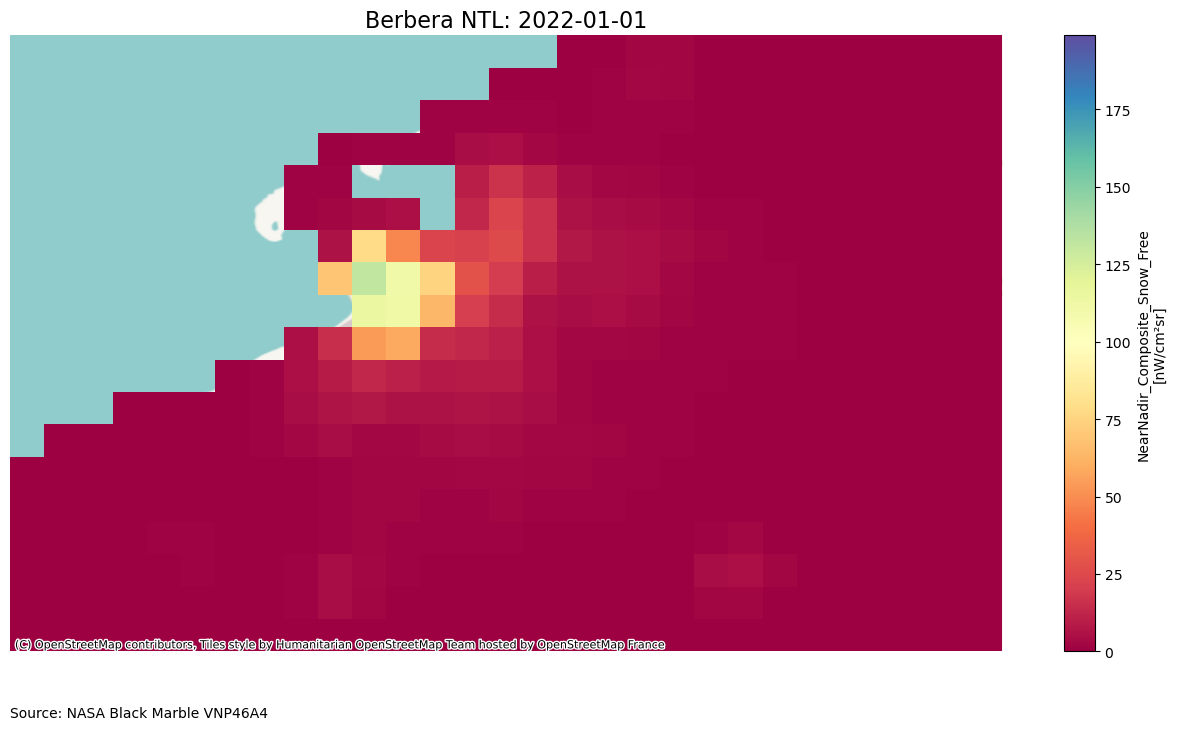

In [9]:
plot_NASA_NTL(Berbera_NTL_ber, Berbera, date = "2022-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Berbera NTL",
              robust = False, vmin=0, vmax = Berbera_NTL_ber["NearNadir_Composite_Snow_Free"].max())
#plt.savefig(f'../output/Graphics/HGA_2012.png', dpi=300, bbox_inches='tight')  